In [2]:
import os
import json
import random
import warnings
from pathlib import Path

import joblib
import numpy as np
import pandas as pd

from sklearn.preprocessing import KBinsDiscretizer
from sklearn.naive_bayes import CategoricalNB
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import roc_auc_score, brier_score_loss, log_loss
from scipy import sparse

warnings.filterwarnings("ignore")

# 1
### Paths

In [3]:
random_seed = 42

random.seed(random_seed)
np.random.seed(random_seed)

project_dir = Path(".")
step1_dir = project_dir / "results_step1"
step2_dir = project_dir / "results_step2"
step4_dir = project_dir / "results_step4_v2"

step4_dir.mkdir(parents=True, exist_ok=True)

pd.set_option("display.max_columns", None)

### 1.2 Load step 1 and step 2 artifacts

In [4]:
train_pairs = pd.read_parquet(step1_dir / "train_pairs.parquet")
val_pairs = pd.read_parquet(step1_dir / "validation_pairs.parquet")
test_pairs = pd.read_parquet(step1_dir / "test_pairs.parquet")

train_split = pd.read_parquet(step1_dir / "train_split_model_universe.parquet")
val_split = pd.read_parquet(step1_dir / "validation_split_model_universe.parquet")
test_split = pd.read_parquet(step1_dir / "test_split_model_universe.parquet")

user_mapping = pd.read_parquet(step2_dir / "user_index_mapping.parquet")
item_mapping = pd.read_parquet(step2_dir / "item_index_mapping.parquet")

user_embeddings = np.load(step2_dir / "user_embeddings_p_u.npy").astype(np.float32)
item_embeddings = np.load(step2_dir / "item_embeddings_q_i.npy").astype(np.float32)
item_bias = np.load(step2_dir / "item_bias.npy").astype(np.float32)

with open(step1_dir / "step1_config.json", "r") as file:
    step1_config = json.load(file)

print("train pairs:", train_pairs.shape)
print("validation pairs:", val_pairs.shape)
print("test pairs:", test_pairs.shape)

print("user embeddings:", user_embeddings.shape)
print("item embeddings:", item_embeddings.shape)
print("item bias:", item_bias.shape)

train pairs: (5692244, 8)
validation pairs: (478098, 8)
test pairs: (507550, 8)
user embeddings: (4722, 64)
item embeddings: (3250, 64)
item bias: (3250,)


### 1.3 Standardize pair columns and add indices

In [5]:
def standardize_pair_columns(pair_df):
    pair_df = pair_df.copy()

    rename_map = {
        "preferred_item": "pos_item",
        "less_preferred_item": "neg_item",
    }

    pair_df = pair_df.rename(columns=rename_map)

    required_columns = [
        "user_id",
        "pos_item",
        "neg_item",
        "rating_preferred",
        "rating_less_preferred",
        "rating_diff",
    ]

    missing_columns = [col for col in required_columns if col not in pair_df.columns]

    if missing_columns:
        raise ValueError(f"missing columns: {missing_columns}")

    return pair_df


def add_pair_indices(pair_df, split_name):
    pair_df = standardize_pair_columns(pair_df)

    user_to_idx = dict(zip(user_mapping["user_id"], user_mapping["user_idx"]))
    item_to_idx = dict(zip(item_mapping["movie_id"], item_mapping["item_idx"]))

    pair_df["user_idx"] = pair_df["user_id"].map(user_to_idx)
    pair_df["pos_item_idx"] = pair_df["pos_item"].map(item_to_idx)
    pair_df["neg_item_idx"] = pair_df["neg_item"].map(item_to_idx)

    before = len(pair_df)

    pair_df = pair_df.dropna(
        subset=[
            "user_idx",
            "pos_item_idx",
            "neg_item_idx",
        ]
    ).copy()

    pair_df["user_idx"] = pair_df["user_idx"].astype(np.int32)
    pair_df["pos_item_idx"] = pair_df["pos_item_idx"].astype(np.int32)
    pair_df["neg_item_idx"] = pair_df["neg_item_idx"].astype(np.int32)

    after = len(pair_df)

    print(f"{split_name}: kept {after:,} / {before:,} pairs")

    return pair_df


train_pairs_idx = add_pair_indices(train_pairs, "train")
val_pairs_idx = add_pair_indices(val_pairs, "validation")
test_pairs_idx = add_pair_indices(test_pairs, "test")

train: kept 5,692,244 / 5,692,244 pairs
validation: kept 478,098 / 478,098 pairs
test: kept 507,550 / 507,550 pairs


### 1.4 Basic checks

In [6]:
n_users, user_dim = user_embeddings.shape
n_items, item_dim = item_embeddings.shape

assert user_dim == item_dim
assert len(user_mapping) == n_users
assert len(item_mapping) == n_items
assert len(item_bias) == n_items

pair_min_diff = int(step1_config.get("pair_min_diff", 2))

for split_name, pair_df in [
    ("train", train_pairs_idx),
    ("validation", val_pairs_idx),
    ("test", test_pairs_idx),
]:
    assert pair_df["rating_diff"].min() >= pair_min_diff
    assert (pair_df["pos_item_idx"] != pair_df["neg_item_idx"]).all()

print("all checks passed")
print("embedding dimension:", user_dim)
print("users:", n_users)
print("items:", n_items)

all checks passed
embedding dimension: 64
users: 4722
items: 3250


### 1.5 Helper functions for metrics

In [7]:
def sigmoid(values):
    values = np.asarray(values, dtype=np.float64)
    values = np.clip(values, -35, 35)
    return 1.0 / (1.0 + np.exp(-values))


def evaluate_forward_probabilities(
    pair_df,
    prob_forward,
    split_name,
    model_name,
    model_family,
    feature_set=None,
    n_bins=None,
    strategy=None,
    alpha=None,
    k=None,
    weighting=None,
):
    prob_forward = np.asarray(prob_forward, dtype=np.float64)
    prob_forward = np.clip(prob_forward, 1e-12, 1.0 - 1e-12)

    correct = prob_forward > 0.5

    user_eval = pd.DataFrame({
        "user_id": pair_df["user_id"].values,
        "correct": correct.astype(float),
    })

    user_accuracy = (
        user_eval
        .groupby("user_id")["correct"]
        .agg(["count", "mean"])
        .reset_index()
        .rename(columns={
            "count": "pairs",
            "mean": "user_accuracy",
        })
    )

    y_true = np.concatenate([
        np.ones(len(prob_forward), dtype=np.int8),
        np.zeros(len(prob_forward), dtype=np.int8),
    ])

    y_prob = np.concatenate([
        prob_forward,
        1.0 - prob_forward,
    ])

    row = {
        "model": model_name,
        "model_family": model_family,
        "split": split_name,
        "feature_set": feature_set,
        "n_bins": n_bins,
        "strategy": strategy,
        "alpha": alpha,
        "k": k,
        "weighting": weighting,

        "original_pairs": int(len(pair_df)),
        "directional_rows": int(2 * len(pair_df)),
        "users": int(pair_df["user_id"].nunique()),

        "accuracy": float(correct.mean()),
        "macro_user_accuracy": float(user_accuracy["user_accuracy"].mean()),
        "median_user_accuracy": float(user_accuracy["user_accuracy"].median()),
        "p10_user_accuracy": float(user_accuracy["user_accuracy"].quantile(0.10)),
        "p25_user_accuracy": float(user_accuracy["user_accuracy"].quantile(0.25)),
        "p75_user_accuracy": float(user_accuracy["user_accuracy"].quantile(0.75)),
        "p90_user_accuracy": float(user_accuracy["user_accuracy"].quantile(0.90)),

        "auc": float(roc_auc_score(y_true, y_prob)),
        "brier_score": float(brier_score_loss(y_true, y_prob)),
        "log_loss": float(log_loss(y_true, y_prob, labels=[0, 1])),
        "mean_forward_probability": float(prob_forward.mean()),
    }

    return row


def is_better_candidate(row, best_row):
    if best_row is None:
        return True

    current_key = (
        -row["macro_user_accuracy"],
        row["brier_score"],
        row["log_loss"],
    )

    best_key = (
        -best_row["macro_user_accuracy"],
        best_row["brier_score"],
        best_row["log_loss"],
    )

    return current_key < best_key

### 1.6 Train sample and evaluation sample

In [8]:
train_pair_sample_n = 300_000
train_eval_sample_n = 300_000

rng = np.random.default_rng(random_seed)

train_sample_idx = rng.choice(
    len(train_pairs_idx),
    size=min(train_pair_sample_n, len(train_pairs_idx)),
    replace=False,
)

train_eval_idx = rng.choice(
    len(train_pairs_idx),
    size=min(train_eval_sample_n, len(train_pairs_idx)),
    replace=False,
)

train_pairs_sample_idx = train_pairs_idx.iloc[train_sample_idx].reset_index(drop=True)
train_pairs_eval_idx = train_pairs_idx.iloc[train_eval_idx].reset_index(drop=True)

print("bayesian training sample:", train_pairs_sample_idx.shape)
print("train evaluation sample:", train_pairs_eval_idx.shape)
print("validation evaluation:", val_pairs_idx.shape)
print("test evaluation:", test_pairs_idx.shape)

bayesian training sample: (300000, 11)
train evaluation sample: (300000, 11)
validation evaluation: (478098, 11)
test evaluation: (507550, 11)


### 1.7 Define function

In [9]:
def compute_mf_margin(pair_df):
    user_idx = pair_df["user_idx"].values
    pos_item_idx = pair_df["pos_item_idx"].values
    neg_item_idx = pair_df["neg_item_idx"].values

    p_u = user_embeddings[user_idx]
    q_pos = item_embeddings[pos_item_idx]
    q_neg = item_embeddings[neg_item_idx]

    margin = np.sum(p_u * (q_pos - q_neg), axis=1)
    margin = margin + item_bias[pos_item_idx] - item_bias[neg_item_idx]

    return margin.astype(np.float32)


mf_rows = []

for split_name, pair_df in [
    ("train_sample", train_pairs_eval_idx),
    ("validation", val_pairs_idx),
    ("test", test_pairs_idx),
]:
    mf_margin = compute_mf_margin(pair_df)
    mf_prob = sigmoid(mf_margin)

    row = evaluate_forward_probabilities(
        pair_df=pair_df,
        prob_forward=mf_prob,
        split_name=split_name,
        model_name="mf_baseline",
        model_family="matrix_factorization",
        feature_set="mf_margin",
    )

    mf_rows.append(row)

mf_baseline_results = pd.DataFrame(mf_rows)

mf_baseline_results

,model,model_family,split,feature_set,n_bins,strategy,alpha,k,weighting,original_pairs,directional_rows,users,accuracy,macro_user_accuracy,median_user_accuracy,p10_user_accuracy,p25_user_accuracy,p75_user_accuracy,p90_user_accuracy,auc,brier_score,log_loss,mean_forward_probability
0,mf_baseline,matrix_factorization,train_sample,mf_margin,None,None,None,None,None,300000,600000,4717,0.939077,0.947161,0.958333,0.875000,0.921053,1.000000,1.0,0.985116,0.050974,0.185189,0.861701
1,mf_baseline,matrix_factorization,validation,mf_margin,None,None,None,None,None,478098,956196,4158,0.808433,0.757608,0.802437,0.483588,0.655379,0.928571,1.0,0.896024,0.131186,0.404075,0.741683
2,mf_baseline,matrix_factorization,test,mf_margin,None,None,None,None,None,507550,1015100,4164,0.817919,0.774139,0.821094,0.500000,0.666667,0.937500,1.0,0.903074,0.126110,0.394358,0.753358


### 1.8 Bayesian feature builder

In [10]:
def build_pair_features(user_idx, first_item_idx, second_item_idx, feature_set):
    user_idx = np.asarray(user_idx, dtype=np.int32)
    first_item_idx = np.asarray(first_item_idx, dtype=np.int32)
    second_item_idx = np.asarray(second_item_idx, dtype=np.int32)

    p_u = user_embeddings[user_idx]
    q_first = item_embeddings[first_item_idx]
    q_second = item_embeddings[second_item_idx]

    q_diff = q_first - q_second

    if feature_set == "user_vector":
        features = p_u

    elif feature_set == "item_vectors":
        features = np.concatenate(
            [
                q_first,
                q_second,
            ],
            axis=1,
        )

    elif feature_set == "item_difference":
        features = q_diff

    elif feature_set == "user_item_interactions":
        features = np.concatenate(
            [
                p_u * q_first,
                p_u * q_second,
            ],
            axis=1,
        )

    elif feature_set == "personalized_difference":
        features = np.concatenate(
            [
                p_u * q_diff,
                q_diff,
            ],
            axis=1,
        )

    elif feature_set == "full_embedding_features":
        features = np.concatenate(
            [
                p_u,
                q_first,
                q_second,
                q_diff,
                p_u * q_first,
                p_u * q_second,
                p_u * q_diff,
            ],
            axis=1,
        )

    else:
        raise ValueError(f"unknown feature set: {feature_set}")

    return features.astype(np.float32)


bayes_feature_sets = [
    "user_vector",
    "item_vectors",
    "item_difference",
    "user_item_interactions",
    "personalized_difference",
    "full_embedding_features",
]

for feature_set in bayes_feature_sets:
    sample_features = build_pair_features(
        user_idx=train_pairs_sample_idx["user_idx"].values[:10],
        first_item_idx=train_pairs_sample_idx["pos_item_idx"].values[:10],
        second_item_idx=train_pairs_sample_idx["neg_item_idx"].values[:10],
        feature_set=feature_set,
    )

    print(feature_set, sample_features.shape[1])

user_vector 64
item_vectors 128
item_difference 64
user_item_interactions 128
personalized_difference 128
full_embedding_features 448


### 1.9 Bayesian training view

In [11]:
def make_random_direction_view(pair_df, seed):
    rng = np.random.default_rng(seed)

    swap = rng.random(len(pair_df)) < 0.5

    user_idx = pair_df["user_idx"].values

    pos_item_idx = pair_df["pos_item_idx"].values
    neg_item_idx = pair_df["neg_item_idx"].values

    first_item_idx = np.where(swap, neg_item_idx, pos_item_idx)
    second_item_idx = np.where(swap, pos_item_idx, neg_item_idx)

    label = np.where(swap, 0, 1).astype(np.int8)

    view = {
        "user_idx": user_idx.astype(np.int32),
        "first_item_idx": first_item_idx.astype(np.int32),
        "second_item_idx": second_item_idx.astype(np.int32),
        "label": label,
    }

    return view


train_view = make_random_direction_view(train_pairs_sample_idx, random_seed)

print("labels:", pd.Series(train_view["label"]).value_counts(normalize=True).sort_index())

labels: 0    0.499597
1    0.500403
Name: proportion, dtype: float64


### 1.10 Bayesian model helpers

In [12]:
def make_discretizer(n_bins, strategy):
    return KBinsDiscretizer(
        n_bins=n_bins,
        encode="ordinal",
        strategy=strategy,
    )


def make_categorical_nb(alpha, n_bins):
    try:
        model = CategoricalNB(
            alpha=alpha,
            min_categories=n_bins,
        )
    except TypeError:
        model = CategoricalNB(
            alpha=alpha,
        )

    return model


def fit_bayes_candidate(train_view, feature_set, n_bins, strategy, alpha):
    x_train = build_pair_features(
        user_idx=train_view["user_idx"],
        first_item_idx=train_view["first_item_idx"],
        second_item_idx=train_view["second_item_idx"],
        feature_set=feature_set,
    )

    y_train = train_view["label"]

    discretizer = make_discretizer(
        n_bins=n_bins,
        strategy=strategy,
    )

    x_train_bin = discretizer.fit_transform(x_train).astype(np.int16)

    model = make_categorical_nb(
        alpha=alpha,
        n_bins=n_bins,
    )

    model.fit(x_train_bin, y_train)

    artifact = {
        "model": model,
        "discretizer": discretizer,
        "feature_set": feature_set,
        "n_bins": int(n_bins),
        "strategy": strategy,
        "alpha": float(alpha),
        "uses_mf_margin": False,
        "uses_item_bias_diff": False,
        "uses_embedding_features": True,
    }

    return artifact


def predict_bayes_prob(pair_df, artifact, chunk_size=100_000):
    model = artifact["model"]
    discretizer = artifact["discretizer"]
    feature_set = artifact["feature_set"]

    class_list = list(model.classes_)

    if 1 not in class_list:
        raise ValueError("bayesian model does not contain class 1")

    prob_col = class_list.index(1)

    probabilities = np.zeros(len(pair_df), dtype=np.float32)

    for start in range(0, len(pair_df), chunk_size):
        end = min(start + chunk_size, len(pair_df))
        part = pair_df.iloc[start:end]

        x_part = build_pair_features(
            user_idx=part["user_idx"].values,
            first_item_idx=part["pos_item_idx"].values,
            second_item_idx=part["neg_item_idx"].values,
            feature_set=feature_set,
        )

        x_part_bin = discretizer.transform(x_part).astype(np.int16)
        probabilities[start:end] = model.predict_proba(x_part_bin)[:, prob_col]

    return probabilities

In [13]:
def predict_bayes_prob_arrays(user_idx, first_item_idx, second_item_idx, artifact, chunk_size=100_000):
    model = artifact["model"]
    discretizer = artifact["discretizer"]
    feature_set = artifact["feature_set"]

    class_list = list(model.classes_)
    prob_col = class_list.index(1)

    probabilities = np.zeros(len(user_idx), dtype=np.float32)

    for start in range(0, len(user_idx), chunk_size):
        end = min(start + chunk_size, len(user_idx))

        x_part = build_pair_features(
            user_idx=user_idx[start:end],
            first_item_idx=first_item_idx[start:end],
            second_item_idx=second_item_idx[start:end],
            feature_set=feature_set,
        )

        x_part_bin = discretizer.transform(x_part).astype(np.int16)
        probabilities[start:end] = model.predict_proba(x_part_bin)[:, prob_col]

    return probabilities

In [14]:
def evaluate_bayes_bidirectional(pair_df, artifact, split_name, model_name):
    user_idx = pair_df["user_idx"].values

    pos_item_idx = pair_df["pos_item_idx"].values
    neg_item_idx = pair_df["neg_item_idx"].values

    prob_forward = predict_bayes_prob_arrays(
        user_idx=user_idx,
        first_item_idx=pos_item_idx,
        second_item_idx=neg_item_idx,
        artifact=artifact,
    )

    prob_reverse = predict_bayes_prob_arrays(
        user_idx=user_idx,
        first_item_idx=neg_item_idx,
        second_item_idx=pos_item_idx,
        artifact=artifact,
    )

    prob_symmetric = 0.5 * (prob_forward + 1.0 - prob_reverse)
    prob_symmetric = np.clip(prob_symmetric, 1e-12, 1.0 - 1e-12)

    row = evaluate_forward_probabilities(
        pair_df=pair_df,
        prob_forward=prob_symmetric,
        split_name=split_name,
        model_name=model_name,
        model_family="bayesian_categorical_nb",
        feature_set=artifact["feature_set"],
        n_bins=artifact["n_bins"],
        strategy=artifact["strategy"],
        alpha=artifact["alpha"],
    )

    row["mean_forward_probability"] = float(prob_forward.mean())
    row["mean_reverse_probability"] = float(prob_reverse.mean())

    row["mean_symmetric_probability"] = float(prob_symmetric.mean())
    row["mean_raw_forward_probability"] = float(prob_forward.mean())
    row["mean_raw_reverse_probability"] = float(prob_reverse.mean())

    row["antisymmetry_error"] = float(
        np.abs(prob_forward + prob_reverse - 1.0).mean()
    )

    return row

### 1.11 Bayesian validation sweep

In [15]:
bayes_n_bins_options = [8, 16]
bayes_strategy_options = ["quantile", "uniform"]
bayes_alpha_options = [0.1, 1.0]

bayes_validation_rows = []
best_bayes_row = None
best_bayes_artifact = None

candidate_count = (
    len(bayes_feature_sets)
    * len(bayes_n_bins_options)
    * len(bayes_strategy_options)
    * len(bayes_alpha_options)
)

candidate_number = 0

for feature_set in bayes_feature_sets:
    for n_bins in bayes_n_bins_options:
        for strategy in bayes_strategy_options:
            for alpha in bayes_alpha_options:
                candidate_number += 1

                print(
                    f"bayes candidate {candidate_number}/{candidate_count}: "
                    f"{feature_set}, bins={n_bins}, strategy={strategy}, alpha={alpha}"
                )

                artifact = fit_bayes_candidate(
                    train_view=train_view,
                    feature_set=feature_set,
                    n_bins=n_bins,
                    strategy=strategy,
                    alpha=alpha,
                )

                row = evaluate_bayes_bidirectional(
                    pair_df=val_pairs_idx,
                    artifact=artifact,
                    split_name="validation",
                    model_name=f"bayes_{feature_set}",
                )

                bayes_validation_rows.append(row)

                if is_better_candidate(row, best_bayes_row):
                    best_bayes_row = row
                    best_bayes_artifact = artifact

bayes_validation_results = (
    pd.DataFrame(bayes_validation_rows)
    .sort_values(
        by=[
            "macro_user_accuracy",
            "brier_score",
            "log_loss",
        ],
        ascending=[
            False,
            True,
            True,
        ],
    )
    .reset_index(drop=True)
)

bayes_validation_results.head(10)

bayes candidate 1/48: user_vector, bins=8, strategy=quantile, alpha=0.1
bayes candidate 2/48: user_vector, bins=8, strategy=quantile, alpha=1.0
bayes candidate 3/48: user_vector, bins=8, strategy=uniform, alpha=0.1
bayes candidate 4/48: user_vector, bins=8, strategy=uniform, alpha=1.0
bayes candidate 5/48: user_vector, bins=16, strategy=quantile, alpha=0.1
bayes candidate 6/48: user_vector, bins=16, strategy=quantile, alpha=1.0
bayes candidate 7/48: user_vector, bins=16, strategy=uniform, alpha=0.1
bayes candidate 8/48: user_vector, bins=16, strategy=uniform, alpha=1.0
bayes candidate 9/48: item_vectors, bins=8, strategy=quantile, alpha=0.1
bayes candidate 10/48: item_vectors, bins=8, strategy=quantile, alpha=1.0
bayes candidate 11/48: item_vectors, bins=8, strategy=uniform, alpha=0.1
bayes candidate 12/48: item_vectors, bins=8, strategy=uniform, alpha=1.0
bayes candidate 13/48: item_vectors, bins=16, strategy=quantile, alpha=0.1
bayes candidate 14/48: item_vectors, bins=16, strategy=q

,model,model_family,split,feature_set,n_bins,strategy,alpha,k,weighting,original_pairs,directional_rows,users,accuracy,macro_user_accuracy,median_user_accuracy,p10_user_accuracy,p25_user_accuracy,p75_user_accuracy,p90_user_accuracy,auc,brier_score,log_loss,mean_forward_probability,mean_reverse_probability,mean_symmetric_probability,mean_raw_forward_probability,mean_raw_reverse_probability,antisymmetry_error
0,bayes_user_item_interactions,bayesian_categorical_nb,validation,user_item_interactions,16,quantile,0.1,None,None,478098,956196,4158,0.800453,0.748360,0.800000,0.444444,0.636102,0.927855,1.0,0.889484,0.179916,1.658191,0.798488,0.201531,0.798478,0.798488,0.201531,0.006076
1,bayes_user_item_interactions,bayesian_categorical_nb,validation,user_item_interactions,16,quantile,1.0,None,None,478098,956196,4158,0.800407,0.748271,0.798681,0.444444,0.634935,0.928215,1.0,0.889465,0.179955,1.658682,0.798449,0.201536,0.798457,0.798449,0.201536,0.005991
2,bayes_user_item_interactions,bayesian_categorical_nb,validation,user_item_interactions,8,quantile,0.1,None,None,478098,956196,4158,0.799378,0.746294,0.793821,0.444444,0.631579,0.925034,1.0,0.888306,0.180869,1.665402,0.797259,0.202609,0.797325,0.797259,0.202609,0.006335
3,bayes_user_item_interactions,bayesian_categorical_nb,validation,user_item_interactions,16,uniform,0.1,None,None,478098,956196,4158,0.800572,0.746069,0.793973,0.444444,0.633333,0.923077,1.0,0.889391,0.173730,1.369233,0.795645,0.201637,0.797004,0.795645,0.201637,0.047855
4,bayes_user_item_interactions,bayesian_categorical_nb,validation,user_item_interactions,8,quantile,1.0,None,None,478098,956196,4158,0.799284,0.746035,0.793103,0.444444,0.630166,0.925000,1.0,0.888322,0.180852,1.664954,0.797203,0.202560,0.797321,0.797203,0.202560,0.006702
5,bayes_user_item_interactions,bayesian_categorical_nb,validation,user_item_interactions,16,uniform,1.0,None,None,478098,956196,4158,0.800309,0.745401,0.791667,0.444444,0.635331,0.924194,1.0,0.889460,0.173668,1.362187,0.795864,0.202450,0.796707,0.795864,0.202450,0.049776
6,bayes_user_item_interactions,bayesian_categorical_nb,validation,user_item_interactions,8,uniform,1.0,None,None,478098,956196,4158,0.799008,0.743505,0.794842,0.444444,0.625000,0.920341,1.0,0.887026,0.167621,1.044354,0.790426,0.206412,0.792007,0.790426,0.206412,0.078278
7,bayes_user_item_interactions,bayesian_categorical_nb,validation,user_item_interactions,8,uniform,0.1,None,None,478098,956196,4158,0.798269,0.742375,0.787879,0.437500,0.625000,0.920312,1.0,0.886269,0.167448,1.035170,0.783698,0.202412,0.790643,0.783698,0.202412,0.086053
8,bayes_personalized_difference,bayesian_categorical_nb,validation,personalized_difference,16,quantile,0.1,None,None,478098,956196,4158,0.786993,0.732127,0.777778,0.421871,0.611111,0.913855,1.0,0.877735,0.204403,3.510004,0.786458,0.212912,0.786773,0.786458,0.212912,0.002847
9,bayes_personalized_difference,bayesian_categorical_nb,validation,personalized_difference,16,quantile,1.0,None,None,478098,956196,4158,0.787069,0.732024,0.777778,0.416667,0.611111,0.913606,1.0,0.877753,0.204389,3.509427,0.786484,0.212907,0.786789,0.786484,0.212907,0.002819


### 1.12 Evaluate best bayesian model

In [16]:
best_bayes_feature_set = best_bayes_artifact["feature_set"]
best_bayes_n_bins = best_bayes_artifact["n_bins"]
best_bayes_strategy = best_bayes_artifact["strategy"]
best_bayes_alpha = best_bayes_artifact["alpha"]

print("best bayesian feature set:", best_bayes_feature_set)
print("best n_bins:", best_bayes_n_bins)
print("best strategy:", best_bayes_strategy)
print("best alpha:", best_bayes_alpha)

bayes_best_rows = []

for split_name, pair_df in [
    ("train_sample", train_pairs_eval_idx),
    ("validation", val_pairs_idx),
    ("test", test_pairs_idx),
]:
    row = evaluate_bayes_bidirectional(
        pair_df=pair_df,
        artifact=best_bayes_artifact,
        split_name=split_name,
        model_name=f"bayes_{best_bayes_feature_set}",
    )

    bayes_best_rows.append(row)

bayes_best_results = pd.DataFrame(bayes_best_rows)

bayes_best_results

best bayesian feature set: user_item_interactions
best n_bins: 16
best strategy: quantile
best alpha: 0.1


,model,model_family,split,feature_set,n_bins,strategy,alpha,k,weighting,original_pairs,directional_rows,users,accuracy,macro_user_accuracy,median_user_accuracy,p10_user_accuracy,p25_user_accuracy,p75_user_accuracy,p90_user_accuracy,auc,brier_score,log_loss,mean_forward_probability,mean_reverse_probability,mean_symmetric_probability,mean_raw_forward_probability,mean_raw_reverse_probability,antisymmetry_error
0,bayes_user_item_interactions,bayesian_categorical_nb,train_sample,user_item_interactions,16,quantile,0.1,None,None,300000,600000,4717,0.919457,0.927988,0.936508,0.851485,0.894737,0.973333,1.0,0.973339,0.071218,0.579676,0.916964,0.082702,0.917131,0.916964,0.082702,0.003363
1,bayes_user_item_interactions,bayesian_categorical_nb,validation,user_item_interactions,16,quantile,0.1,None,None,478098,956196,4158,0.800453,0.748360,0.800000,0.444444,0.636102,0.927855,1.0,0.889484,0.179916,1.658191,0.798488,0.201531,0.798478,0.798488,0.201531,0.006076
2,bayes_user_item_interactions,bayesian_categorical_nb,test,user_item_interactions,16,quantile,0.1,None,None,507550,1015100,4164,0.811605,0.765294,0.812500,0.500000,0.666667,0.933333,1.0,0.897973,0.170505,1.668127,0.809655,0.190214,0.809720,0.809655,0.190214,0.005556


### 1.13 Bayesian feature summary

In [17]:
bayes_feature_summary = (
    bayes_validation_results
    .groupby("feature_set")
    .agg(
        candidates=("model", "count"),
        best_macro_user_accuracy=("macro_user_accuracy", "max"),
        best_accuracy=("accuracy", "max"),
        best_auc=("auc", "max"),
        best_brier_score=("brier_score", "min"),
        best_log_loss=("log_loss", "min"),
    )
    .reset_index()
    .sort_values(
        by=[
            "best_macro_user_accuracy",
            "best_brier_score",
        ],
        ascending=[
            False,
            True,
        ],
    )
)

bayes_feature_summary

,feature_set,candidates,best_macro_user_accuracy,best_accuracy,best_auc,best_brier_score,best_log_loss
4,user_item_interactions,8,0.748360,0.800572,0.889484,0.167448,1.035170
3,personalized_difference,8,0.732127,0.787069,0.877753,0.199617,2.962025
0,full_embedding_features,8,0.731907,0.786209,0.874913,0.206831,4.196822
2,item_vectors,8,0.708299,0.768483,0.857446,0.216935,2.828549
1,item_difference,8,0.708161,0.769715,0.859335,0.213710,2.568091
5,user_vector,8,0.000000,0.000000,0.351103,0.250000,0.693147


### 1.14 Bayesian pairwise-to-ranking conversion helper

In [18]:
item_idx_to_movie_id = dict(zip(item_mapping["item_idx"], item_mapping["movie_id"]))
movie_id_to_item_idx = dict(zip(item_mapping["movie_id"], item_mapping["item_idx"]))
user_id_to_user_idx = dict(zip(user_mapping["user_id"], user_mapping["user_idx"]))


def predict_bayes_pair_array(user_idx, first_item_idx, second_item_idx, artifact, chunk_size=100_000):
    user_idx = np.asarray(user_idx, dtype=np.int32)
    first_item_idx = np.asarray(first_item_idx, dtype=np.int32)
    second_item_idx = np.asarray(second_item_idx, dtype=np.int32)

    return predict_bayes_prob_arrays(
        user_idx=user_idx,
        first_item_idx=first_item_idx,
        second_item_idx=second_item_idx,
        artifact=artifact,
        chunk_size=chunk_size,
    )


def get_bayes_borda_scores(user_idx, candidate_item_idx, artifact, opponent_sample_n=None, seed=42, chunk_size=100_000):
    candidate_item_idx = np.asarray(candidate_item_idx, dtype=np.int32)
    candidate_item_idx = np.unique(candidate_item_idx)

    if len(candidate_item_idx) < 2:
        raise ValueError("candidate_item_idx must contain at least two items")

    rng = np.random.default_rng(seed)

    score_sum = np.zeros(len(candidate_item_idx), dtype=np.float64)
    score_count = np.zeros(len(candidate_item_idx), dtype=np.float64)

    for pos in range(len(candidate_item_idx)):
        first_item = candidate_item_idx[pos]

        opponents = candidate_item_idx[candidate_item_idx != first_item]

        if opponent_sample_n is not None and len(opponents) > opponent_sample_n:
            opponents = rng.choice(
                opponents,
                size=opponent_sample_n,
                replace=False,
            )

        user_array = np.full(len(opponents), user_idx, dtype=np.int32)
        first_array = np.full(len(opponents), first_item, dtype=np.int32)
        second_array = opponents.astype(np.int32)

        prob_forward = predict_bayes_pair_array(
            user_idx=user_array,
            first_item_idx=first_array,
            second_item_idx=second_array,
            artifact=artifact,
            chunk_size=chunk_size,
        )

        prob_reverse = predict_bayes_pair_array(
            user_idx=user_array,
            first_item_idx=second_array,
            second_item_idx=first_array,
            artifact=artifact,
            chunk_size=chunk_size,
        )

        prob_symmetric = 0.5 * (prob_forward + 1.0 - prob_reverse)
        prob_symmetric = np.clip(prob_symmetric, 1e-12, 1.0 - 1e-12)

        score_sum[pos] = prob_symmetric.sum()
        score_count[pos] = len(prob_symmetric)

    bayes_score = score_sum / np.maximum(score_count, 1)

    result = pd.DataFrame({
        "item_idx": candidate_item_idx,
        "movie_id": [item_idx_to_movie_id[int(idx)] for idx in candidate_item_idx],
        "bayes_borda_score": bayes_score,
    })

    result = result.sort_values(
        "bayes_borda_score",
        ascending=False,
    ).reset_index(drop=True)

    return result

### 1.15 Check for bayesian borda helper

In [19]:
example_user_idx = int(val_pairs_idx["user_idx"].iloc[0])

example_candidate_item_idx = (
    val_pairs_idx
    .loc[val_pairs_idx["user_idx"] == example_user_idx, ["pos_item_idx", "neg_item_idx"]]
    .head(20)
    .values
    .reshape(-1)
)

example_bayes_borda = get_bayes_borda_scores(
    user_idx=example_user_idx,
    candidate_item_idx=example_candidate_item_idx,
    artifact=best_bayes_artifact,
    opponent_sample_n=None,
)

example_bayes_borda.head(10)

,item_idx,movie_id,bayes_borda_score
0,535,595,0.999750
1,0,1,0.658656
2,622,745,0.271088
3,2185,2687,0.070506


### 1.16 User kNN data preparation

In [20]:
def add_indices_to_ratings(ratings_df):
    ratings_df = ratings_df.copy()

    ratings_df["user_idx"] = ratings_df["user_id"].map(user_id_to_user_idx)
    ratings_df["item_idx"] = ratings_df["movie_id"].map(movie_id_to_item_idx)

    before = len(ratings_df)
    ratings_df = ratings_df.dropna(subset=["user_idx", "item_idx", "rating"]).copy()
    after = len(ratings_df)

    ratings_df["user_idx"] = ratings_df["user_idx"].astype(np.int32)
    ratings_df["item_idx"] = ratings_df["item_idx"].astype(np.int32)
    ratings_df["rating"] = ratings_df["rating"].astype(np.float32)

    print(f"ratings indexed: kept {after:,} / {before:,} rows")

    return ratings_df


train_ratings_idx = add_indices_to_ratings(train_split)

global_rating_mean = float(train_ratings_idx["rating"].mean())

user_rating_sum = np.bincount(
    train_ratings_idx["user_idx"].values,
    weights=train_ratings_idx["rating"].values,
    minlength=n_users,
).astype(np.float64)

user_rating_count = np.bincount(
    train_ratings_idx["user_idx"].values,
    minlength=n_users,
).astype(np.float64)

user_rating_mean = np.divide(
    user_rating_sum,
    np.maximum(user_rating_count, 1.0),
)
user_rating_mean[user_rating_count == 0] = global_rating_mean

item_rating_sum = np.bincount(
    train_ratings_idx["item_idx"].values,
    weights=train_ratings_idx["rating"].values,
    minlength=n_items,
).astype(np.float64)

item_rating_count = np.bincount(
    train_ratings_idx["item_idx"].values,
    minlength=n_items,
).astype(np.float64)

item_rating_mean = np.divide(
    item_rating_sum,
    np.maximum(item_rating_count, 1.0),
)
item_rating_mean[item_rating_count == 0] = global_rating_mean

centered_rating_values = (
    train_ratings_idx["rating"].values
    - user_rating_mean[train_ratings_idx["user_idx"].values]
).astype(np.float32)

centered_rating_matrix = sparse.csr_matrix(
    (
        centered_rating_values,
        (
            train_ratings_idx["user_idx"].values,
            train_ratings_idx["item_idx"].values,
        ),
    ),
    shape=(n_users, n_items),
    dtype=np.float32,
)

rating_presence_matrix = sparse.csr_matrix(
    (
        np.ones(len(train_ratings_idx), dtype=np.float32),
        (
            train_ratings_idx["user_idx"].values,
            train_ratings_idx["item_idx"].values,
        ),
    ),
    shape=(n_users, n_items),
    dtype=np.float32,
)

print("centered rating matrix:", centered_rating_matrix.shape)
print("train rating density:", centered_rating_matrix.nnz / (n_users * n_items))
print("global train rating mean:", global_rating_mean)

ratings indexed: kept 759,306 / 759,306 rows
centered rating matrix: (4722, 3250)
train rating density: 0.04947747043299775
global train rating mean: 3.6125566959381104


### 1.17 Rating based nearest users

In [21]:
max_knn_k = 50

rating_neighbor_model = NearestNeighbors(
    n_neighbors=max_knn_k + 1,
    metric="cosine",
    algorithm="brute",
)

rating_neighbor_model.fit(centered_rating_matrix)

neighbor_distances_raw, neighbor_indices_raw = rating_neighbor_model.kneighbors(centered_rating_matrix)


def remove_self_neighbors(neighbor_indices, neighbor_distances, max_k):
    clean_indices = np.empty((neighbor_indices.shape[0], max_k), dtype=np.int32)
    clean_distances = np.empty((neighbor_indices.shape[0], max_k), dtype=np.float32)

    for row_idx in range(neighbor_indices.shape[0]):
        row_indices = neighbor_indices[row_idx]
        row_distances = neighbor_distances[row_idx]

        keep_mask = row_indices != row_idx
        kept_indices = row_indices[keep_mask][:max_k]
        kept_distances = row_distances[keep_mask][:max_k]

        if len(kept_indices) < max_k:
            fill_count = max_k - len(kept_indices)
            fallback_index = kept_indices[-1] if len(kept_indices) > 0 else row_idx
            fallback_distance = kept_distances[-1] if len(kept_distances) > 0 else 1.0

            kept_indices = np.concatenate([
                kept_indices,
                np.full(fill_count, fallback_index, dtype=kept_indices.dtype),
            ])
            kept_distances = np.concatenate([
                kept_distances,
                np.full(fill_count, fallback_distance, dtype=kept_distances.dtype),
            ])

        clean_indices[row_idx] = kept_indices.astype(np.int32)
        clean_distances[row_idx] = kept_distances.astype(np.float32)

    return clean_indices, clean_distances


user_neighbor_indices, user_neighbor_distances = remove_self_neighbors(
    neighbor_indices=neighbor_indices_raw,
    neighbor_distances=neighbor_distances_raw,
    max_k=max_knn_k,
)

assert user_neighbor_indices.shape == (n_users, max_knn_k)
assert user_neighbor_distances.shape == (n_users, max_knn_k)

print("rating-kNN neighbor indices:", user_neighbor_indices.shape)
print("rating-kNN neighbor distances:", user_neighbor_distances.shape)

rating-kNN neighbor indices: (4722, 50)
rating-kNN neighbor distances: (4722, 50)


### 1.18 Rating based user kNN scorer

In [22]:
def compute_rating_user_knn_score_matrix(k, weighting, batch_size=64):
    if k > user_neighbor_indices.shape[1]:
        raise ValueError(f"k={k} exceeds available neighbors")

    result = np.zeros((n_users, n_items), dtype=np.float32)
    fallback_item_scores = item_rating_mean.astype(np.float32)

    for start in range(0, n_users, batch_size):
        end = min(start + batch_size, n_users)
        batch_user_idx = np.arange(start, end, dtype=np.int32)

        neighbor_idx = user_neighbor_indices[start:end, :k]
        neighbor_dist = user_neighbor_distances[start:end, :k]

        if weighting == "uniform":
            weights = np.full(
                shape=neighbor_idx.shape,
                fill_value=1.0 / k,
                dtype=np.float32,
            )

        elif weighting == "similarity":
            weights = np.clip(1.0 - neighbor_dist, 0.0, None).astype(np.float32)
            weight_sum = weights.sum(axis=1, keepdims=True)
            zero_rows = weight_sum.reshape(-1) <= 1e-12

            if zero_rows.any():
                weights[zero_rows, :] = 1.0
                weight_sum[zero_rows, :] = float(k)

            weights = weights / weight_sum

        else:
            raise ValueError(f"unknown weighting: {weighting}")

        flat_neighbor_idx = neighbor_idx.reshape(-1)

        neighbor_centered = centered_rating_matrix[flat_neighbor_idx].toarray().reshape(
            end - start,
            k,
            n_items,
        ).astype(np.float32)

        neighbor_presence = rating_presence_matrix[flat_neighbor_idx].toarray().reshape(
            end - start,
            k,
            n_items,
        ).astype(np.float32)

        numerator = np.einsum("bk,bki->bi", weights, neighbor_centered)
        denominator = np.einsum("bk,bki->bi", weights, neighbor_presence)

        batch_scores = np.tile(fallback_item_scores.reshape(1, -1), (end - start, 1))
        observed_mask = denominator > 1e-12

        centered_prediction = np.zeros_like(numerator, dtype=np.float32)
        centered_prediction[observed_mask] = numerator[observed_mask] / denominator[observed_mask]

        user_base = user_rating_mean[batch_user_idx].astype(np.float32).reshape(-1, 1)
        batch_scores[observed_mask] = (user_base + centered_prediction)[observed_mask]

        result[start:end] = np.clip(batch_scores, 1.0, 5.0).astype(np.float32)

    return result


def compute_rating_user_knn_margin(pair_df, knn_score_matrix):
    user_idx = pair_df["user_idx"].values
    pos_item_idx = pair_df["pos_item_idx"].values
    neg_item_idx = pair_df["neg_item_idx"].values

    margin = (
        knn_score_matrix[user_idx, pos_item_idx]
        - knn_score_matrix[user_idx, neg_item_idx]
    )

    return margin.astype(np.float32)

### 1.19 Rating based user kNN validation sweep

In [23]:
knn_k_options = [10, 20, 50]
knn_weighting_options = ["uniform", "similarity"]

knn_validation_rows = []
best_knn_row = None
best_knn_score_matrix = None

for k in knn_k_options:
    for weighting in knn_weighting_options:
        print(f"rating-user-kNN candidate: k={k}, weighting={weighting}")

        knn_score_matrix = compute_rating_user_knn_score_matrix(
            k=k,
            weighting=weighting,
        )

        val_knn_margin = compute_rating_user_knn_margin(
            pair_df=val_pairs_idx,
            knn_score_matrix=knn_score_matrix,
        )

        val_knn_prob = sigmoid(val_knn_margin)

        row = evaluate_forward_probabilities(
            pair_df=val_pairs_idx,
            prob_forward=val_knn_prob,
            split_name="validation",
            model_name=f"rating_user_knn_k_{k}_{weighting}",
            model_family="rating_user_knn",
            feature_set="centered_train_ratings",
            k=k,
            weighting=weighting,
        )

        knn_validation_rows.append(row)

        if is_better_candidate(row, best_knn_row):
            best_knn_row = row
            best_knn_score_matrix = knn_score_matrix.copy()

        del knn_score_matrix

knn_validation_results = (
    pd.DataFrame(knn_validation_rows)
    .sort_values(
        by=[
            "macro_user_accuracy",
            "brier_score",
            "log_loss",
        ],
        ascending=[
            False,
            True,
            True,
        ],
    )
    .reset_index(drop=True)
)

knn_validation_results

rating-user-kNN candidate: k=10, weighting=uniform
rating-user-kNN candidate: k=10, weighting=similarity
rating-user-kNN candidate: k=20, weighting=uniform
rating-user-kNN candidate: k=20, weighting=similarity
rating-user-kNN candidate: k=50, weighting=uniform
rating-user-kNN candidate: k=50, weighting=similarity


,model,model_family,split,feature_set,n_bins,strategy,alpha,k,weighting,original_pairs,directional_rows,users,accuracy,macro_user_accuracy,median_user_accuracy,p10_user_accuracy,p25_user_accuracy,p75_user_accuracy,p90_user_accuracy,auc,brier_score,log_loss,mean_forward_probability
0,rating_user_knn_k_50_uniform,rating_user_knn,validation,centered_train_ratings,None,None,None,50,uniform,478098,956196,4158,0.773410,0.706558,0.750000,0.400000,0.571905,0.882291,1.0,0.855531,0.163029,0.498905,0.637938
1,rating_user_knn_k_50_similarity,rating_user_knn,validation,centered_train_ratings,None,None,None,50,similarity,478098,956196,4158,0.774224,0.706262,0.750000,0.382353,0.574784,0.887062,1.0,0.856447,0.162566,0.497800,0.638686
2,rating_user_knn_k_20_similarity,rating_user_knn,validation,centered_train_ratings,None,None,None,20,similarity,478098,956196,4158,0.752538,0.677953,0.718246,0.333333,0.534711,0.862069,1.0,0.833642,0.169584,0.512943,0.637029
3,rating_user_knn_k_20_uniform,rating_user_knn,validation,centered_train_ratings,None,None,None,20,uniform,478098,956196,4158,0.751586,0.676598,0.714286,0.333333,0.533333,0.863636,1.0,0.832870,0.169934,0.513756,0.636514
4,rating_user_knn_k_10_similarity,rating_user_knn,validation,centered_train_ratings,None,None,None,10,similarity,478098,956196,4158,0.738413,0.669494,0.704314,0.333333,0.521739,0.857143,1.0,0.819389,0.174871,0.524803,0.634218
5,rating_user_knn_k_10_uniform,rating_user_knn,validation,centered_train_ratings,None,None,None,10,uniform,478098,956196,4158,0.737943,0.668210,0.700000,0.333333,0.520000,0.857143,1.0,0.818939,0.175075,0.525281,0.633895


### 1.20 Evaluate best independent rating user kNN model

In [24]:
best_knn_k = int(best_knn_row["k"])
best_knn_weighting = best_knn_row["weighting"]

print("best rating-user-kNN k:", best_knn_k)
print("best rating-user-kNN weighting:", best_knn_weighting)

knn_best_rows = []

for split_name, pair_df in [
    ("train_sample", train_pairs_eval_idx),
    ("validation", val_pairs_idx),
    ("test", test_pairs_idx),
]:
    knn_margin = compute_rating_user_knn_margin(
        pair_df=pair_df,
        knn_score_matrix=best_knn_score_matrix,
    )

    knn_prob = sigmoid(knn_margin)

    row = evaluate_forward_probabilities(
        pair_df=pair_df,
        prob_forward=knn_prob,
        split_name=split_name,
        model_name=f"rating_user_knn_k_{best_knn_k}_{best_knn_weighting}",
        model_family="rating_user_knn",
        feature_set="centered_train_ratings",
        k=best_knn_k,
        weighting=best_knn_weighting,
    )

    knn_best_rows.append(row)

knn_best_results = pd.DataFrame(knn_best_rows)

knn_best_results

best rating-user-kNN k: 50
best rating-user-kNN weighting: uniform


,model,model_family,split,feature_set,n_bins,strategy,alpha,k,weighting,original_pairs,directional_rows,users,accuracy,macro_user_accuracy,median_user_accuracy,p10_user_accuracy,p25_user_accuracy,p75_user_accuracy,p90_user_accuracy,auc,brier_score,log_loss,mean_forward_probability
0,rating_user_knn_k_50_uniform,rating_user_knn,train_sample,centered_train_ratings,None,None,None,50,uniform,300000,600000,4717,0.912617,0.932404,0.940594,0.849403,0.894737,1.000000,1.0,0.969226,0.098573,0.349697,0.724308
1,rating_user_knn_k_50_uniform,rating_user_knn,validation,centered_train_ratings,None,None,None,50,uniform,478098,956196,4158,0.773410,0.706558,0.750000,0.400000,0.571905,0.882291,1.0,0.855531,0.163029,0.498905,0.637938
2,rating_user_knn_k_50_uniform,rating_user_knn,test,centered_train_ratings,None,None,None,50,uniform,507550,1015100,4164,0.778725,0.713992,0.758153,0.400000,0.586635,0.890625,1.0,0.859784,0.159424,0.490201,0.646041


### 1.21 Final comparison

In [25]:
final_model_comparison = pd.concat(
    [
        mf_baseline_results,
        bayes_best_results,
        knn_best_results,
    ],
    ignore_index=True,
)

final_model_comparison = final_model_comparison.sort_values(
    by=[
        "split",
        "macro_user_accuracy",
        "brier_score",
    ],
    ascending=[
        True,
        False,
        True,
    ],
).reset_index(drop=True)

compact_model_comparison = final_model_comparison[
    [
        "model",
        "model_family",
        "split",
        "feature_set",
        "accuracy",
        "macro_user_accuracy",
        "auc",
        "brier_score",
        "log_loss",
        "mean_forward_probability",
        "n_bins",
        "strategy",
        "alpha",
        "k",
        "weighting",
    ]
].copy()

compact_model_comparison

,model,model_family,split,feature_set,accuracy,macro_user_accuracy,auc,brier_score,log_loss,mean_forward_probability,n_bins,strategy,alpha,k,weighting
0,mf_baseline,matrix_factorization,test,mf_margin,0.817919,0.774139,0.903074,0.126110,0.394358,0.753358,None,None,None,None,None
1,bayes_user_item_interactions,bayesian_categorical_nb,test,user_item_interactions,0.811605,0.765294,0.897973,0.170505,1.668127,0.809655,16,quantile,0.1,None,None
2,rating_user_knn_k_50_uniform,rating_user_knn,test,centered_train_ratings,0.778725,0.713992,0.859784,0.159424,0.490201,0.646041,None,None,None,50,uniform
3,mf_baseline,matrix_factorization,train_sample,mf_margin,0.939077,0.947161,0.985116,0.050974,0.185189,0.861701,None,None,None,None,None
4,rating_user_knn_k_50_uniform,rating_user_knn,train_sample,centered_train_ratings,0.912617,0.932404,0.969226,0.098573,0.349697,0.724308,None,None,None,50,uniform
5,bayes_user_item_interactions,bayesian_categorical_nb,train_sample,user_item_interactions,0.919457,0.927988,0.973339,0.071218,0.579676,0.916964,16,quantile,0.1,None,None
6,mf_baseline,matrix_factorization,validation,mf_margin,0.808433,0.757608,0.896024,0.131186,0.404075,0.741683,None,None,None,None,None
7,bayes_user_item_interactions,bayesian_categorical_nb,validation,user_item_interactions,0.800453,0.748360,0.889484,0.179916,1.658191,0.798488,16,quantile,0.1,None,None
8,rating_user_knn_k_50_uniform,rating_user_knn,validation,centered_train_ratings,0.773410,0.706558,0.855531,0.163029,0.498905,0.637938,None,None,None,50,uniform


### 1.22 Calibration comparison

In [26]:
calibration_comparison = compact_model_comparison[
    [
        "model",
        "model_family",
        "split",
        "feature_set",
        "brier_score",
        "log_loss",
        "mean_forward_probability",
    ]
].copy()

calibration_comparison.sort_values(
    by=[
        "split",
        "brier_score",
        "log_loss",
    ],
    ascending=[
        True,
        True,
        True,
    ],
)

,model,model_family,split,feature_set,brier_score,log_loss,mean_forward_probability
0,mf_baseline,matrix_factorization,test,mf_margin,0.126110,0.394358,0.753358
2,rating_user_knn_k_50_uniform,rating_user_knn,test,centered_train_ratings,0.159424,0.490201,0.646041
1,bayes_user_item_interactions,bayesian_categorical_nb,test,user_item_interactions,0.170505,1.668127,0.809655
3,mf_baseline,matrix_factorization,train_sample,mf_margin,0.050974,0.185189,0.861701
5,bayes_user_item_interactions,bayesian_categorical_nb,train_sample,user_item_interactions,0.071218,0.579676,0.916964
4,rating_user_knn_k_50_uniform,rating_user_knn,train_sample,centered_train_ratings,0.098573,0.349697,0.724308
6,mf_baseline,matrix_factorization,validation,mf_margin,0.131186,0.404075,0.741683
8,rating_user_knn_k_50_uniform,rating_user_knn,validation,centered_train_ratings,0.163029,0.498905,0.637938
7,bayes_user_item_interactions,bayesian_categorical_nb,validation,user_item_interactions,0.179916,1.658191,0.798488


### 1.23 Plots

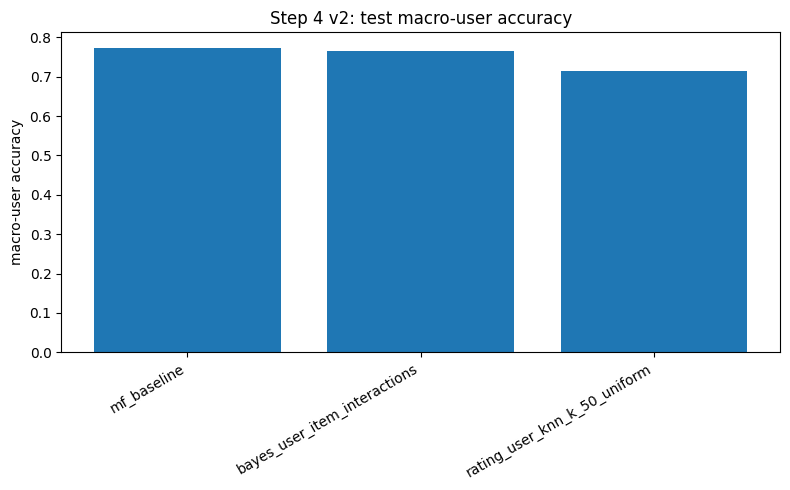

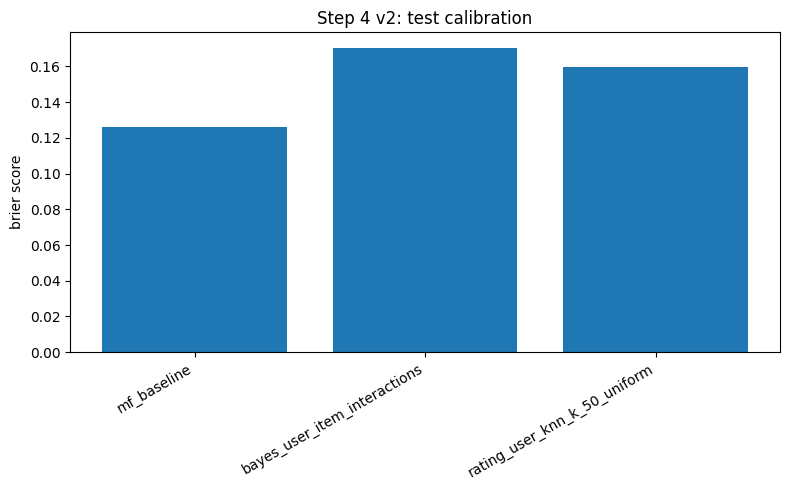

In [27]:
import matplotlib.pyplot as plt

test_rows = compact_model_comparison[
    compact_model_comparison["split"] == "test"
].copy()

test_rows = test_rows.sort_values("macro_user_accuracy", ascending=False)

plt.figure(figsize=(8, 5))
plt.bar(
    test_rows["model"],
    test_rows["macro_user_accuracy"],
)
plt.xticks(rotation=30, ha="right")
plt.ylabel("macro-user accuracy")
plt.title("Step 4 v2: test macro-user accuracy")
plt.tight_layout()
plt.savefig(step4_dir / "test_macro_user_accuracy.png", dpi=150)
plt.show()

plt.figure(figsize=(8, 5))
plt.bar(
    test_rows["model"],
    test_rows["brier_score"],
)
plt.xticks(rotation=30, ha="right")
plt.ylabel("brier score")
plt.title("Step 4 v2: test calibration")
plt.tight_layout()
plt.savefig(step4_dir / "test_brier_score.png", dpi=150)
plt.show()

### 1.24 When does kNN beat MF?

In [28]:
def compare_mf_knn_by_user(pair_df, knn_score_matrix, split_name):
    mf_margin = compute_mf_margin(pair_df)
    knn_margin = compute_rating_user_knn_margin(pair_df, knn_score_matrix)

    comparison = pd.DataFrame({
        "user_id": pair_df["user_id"].values,
        "mf_correct": mf_margin > 0,
        "knn_correct": knn_margin > 0,
    })

    user_summary = (
        comparison
        .groupby("user_id")
        .agg(
            pairs=("mf_correct", "size"),
            mf_accuracy=("mf_correct", "mean"),
            knn_accuracy=("knn_correct", "mean"),
        )
        .reset_index()
    )

    user_summary["knn_minus_mf"] = user_summary["knn_accuracy"] - user_summary["mf_accuracy"]

    user_summary["pair_count_bin"] = pd.qcut(
        user_summary["pairs"],
        q=4,
        duplicates="drop",
    )

    bin_summary = (
        user_summary
        .groupby("pair_count_bin", observed=False)
        .agg(
            users=("user_id", "count"),
            mean_pairs=("pairs", "mean"),
            mf_accuracy=("mf_accuracy", "mean"),
            knn_accuracy=("knn_accuracy", "mean"),
            mean_knn_minus_mf=("knn_minus_mf", "mean"),
            share_users_knn_beats_mf=("knn_minus_mf", lambda x: float((x > 0).mean())),
        )
        .reset_index()
    )

    bin_summary["split"] = split_name

    return user_summary, bin_summary


val_user_knn_vs_mf, val_knn_vs_mf_bins = compare_mf_knn_by_user(
    pair_df=val_pairs_idx,
    knn_score_matrix=best_knn_score_matrix,
    split_name="validation",
)

test_user_knn_vs_mf, test_knn_vs_mf_bins = compare_mf_knn_by_user(
    pair_df=test_pairs_idx,
    knn_score_matrix=best_knn_score_matrix,
    split_name="test",
)

knn_vs_mf_bins = pd.concat(
    [val_knn_vs_mf_bins, test_knn_vs_mf_bins],
    ignore_index=True,
)

knn_vs_mf_bins

,pair_count_bin,users,mean_pairs,mf_accuracy,knn_accuracy,mean_knn_minus_mf,share_users_knn_beats_mf,split
0,"(0.999, 8.0]",1079,4.610751,0.721059,0.676224,-0.044835,0.243744,validation
1,"(8.0, 25.5]",1000,15.534000,0.741988,0.673750,-0.068238,0.307000,validation
2,"(25.5, 90.0]",1051,49.933397,0.763724,0.708650,-0.055073,0.312084,validation
3,"(90.0, 6620.0]",1028,394.074903,0.804912,0.768171,-0.036741,0.299611,validation
4,"(0.999, 9.0]",1129,5.045173,0.741475,0.661500,-0.079975,0.228521,test
5,"(9.0, 27.0]",974,16.840862,0.762549,0.704543,-0.058006,0.310062,test
6,"(27.0, 94.0]",1022,53.375734,0.775518,0.715961,-0.059558,0.302348,test
7,"(94.0, 6954.0]",1039,414.726660,0.819139,0.777951,-0.041187,0.266603,test


# Save Results

In [29]:
def make_json_safe(value):
    if isinstance(value, np.integer):
        return int(value)

    if isinstance(value, np.floating):
        return float(value)

    if isinstance(value, np.ndarray):
        return value.tolist()

    if pd.isna(value):
        return None

    return value


tables_to_save = {
    "mf_baseline_results.parquet": mf_baseline_results,
    "bayes_validation_results.parquet": bayes_validation_results,
    "bayes_feature_summary.parquet": bayes_feature_summary,
    "bayes_best_results.parquet": bayes_best_results,
    "knn_validation_results.parquet": knn_validation_results,
    "knn_best_results.parquet": knn_best_results,
    "final_model_comparison.parquet": final_model_comparison,
    "compact_model_comparison.parquet": compact_model_comparison,
    "calibration_comparison.parquet": calibration_comparison,
}

for file_name, table in tables_to_save.items():
    table.to_parquet(step4_dir / file_name, index=False)
    table.to_csv(step4_dir / file_name.replace(".parquet", ".csv"), index=False)

bayesian_artifact_to_save = {
    "model": best_bayes_artifact["model"],
    "discretizer": best_bayes_artifact["discretizer"],
    "feature_set": best_bayes_artifact["feature_set"],
    "n_bins": best_bayes_artifact["n_bins"],
    "strategy": best_bayes_artifact["strategy"],
    "alpha": best_bayes_artifact["alpha"],
    "feature_sets_tested": bayes_feature_sets,
    "uses_mf_margin": False,
    "uses_item_bias_diff": False,
    "uses_embedding_features": True,
    "note": "categorical naive bayes trained on discretized BPR/MF embedding-derived pairwise features",
}

joblib.dump(
    bayesian_artifact_to_save,
    step4_dir / "best_bayesian_categorical_nb_v2.joblib",
)

np.save(
    step4_dir / "best_rating_user_knn_score_matrix.npy",
    best_knn_score_matrix.astype(np.float32),
)

np.save(
    step4_dir / "best_knn_neighbor_indices.npy",
    user_neighbor_indices[:, :best_knn_k],
)

np.save(
    step4_dir / "best_knn_neighbor_distances.npy",
    user_neighbor_distances[:, :best_knn_k],
)

np.save(
    step4_dir / "rating_user_mean.npy",
    user_rating_mean.astype(np.float32),
)

np.save(
    step4_dir / "rating_item_mean.npy",
    item_rating_mean.astype(np.float32),
)

knn_config = {
    "k": int(best_knn_k),
    "weighting": best_knn_weighting,
    "metric": "cosine",
    "neighbor_space": "centered_train_rating_vectors",
    "score_definition": "user mean plus weighted average of neighbors' centered train ratings, with item-mean fallback",
    "uses_mf_scores": False,
    "uses_mf_embeddings": False,
    "uses_dbscan": False,
}

score_sources_config = {
    "mf_score": "p_u dot q_i plus item_bias_i",
    "bayesian_score": "borda tournament aggregation of bayesian pairwise probabilities within candidate pool",
    "knn_score": "independent rating-based user-kNN over centered train ratings",
    "hybrid_ready": True,
    "dbscan_used": False,
    "bayesian_feature_set": best_bayes_feature_set,
    "bayesian_n_bins": int(best_bayes_n_bins),
    "bayesian_strategy": best_bayes_strategy,
    "bayesian_alpha": float(best_bayes_alpha),
    "knn_k": int(best_knn_k),
    "knn_weighting": best_knn_weighting,
}

step4_config = {
    "random_seed": random_seed,
    "train_pair_sample_n": int(train_pair_sample_n),
    "train_eval_sample_n": int(train_eval_sample_n),
    "bayes_feature_sets": bayes_feature_sets,
    "bayes_n_bins_options": bayes_n_bins_options,
    "bayes_strategy_options": bayes_strategy_options,
    "bayes_alpha_options": bayes_alpha_options,
    "best_bayesian": {
        "feature_set": best_bayes_feature_set,
        "n_bins": int(best_bayes_n_bins),
        "strategy": best_bayes_strategy,
        "alpha": float(best_bayes_alpha),
    },
    "best_knn": knn_config,
    "score_sources": score_sources_config,
}

with open(step4_dir / "best_knn_config.json", "w") as file:
    json.dump(
        {key: make_json_safe(value) for key, value in knn_config.items()},
        file,
        indent=2,
    )

with open(step4_dir / "step4_score_sources_config.json", "w") as file:
    json.dump(
        {key: make_json_safe(value) for key, value in score_sources_config.items()},
        file,
        indent=2,
    )

with open(step4_dir / "step4_v2_config.json", "w") as file:
    json.dump(
        step4_config,
        file,
        indent=2,
        default=make_json_safe,
    )

print("saved results to:", step4_dir)

saved results to: results_step4_v2


In [30]:
saved_files = []

for path in sorted(step4_dir.iterdir()):
    if path.is_file():
        saved_files.append({
            "file": path.name,
        })

saved_file_summary = pd.DataFrame(saved_files)

saved_file_summary

,file
0,bayes_best_results.csv
1,bayes_best_results.parquet
2,bayes_feature_summary.csv
3,bayes_feature_summary.parquet
4,bayes_validation_results.csv
5,bayes_validation_results.parquet
6,best_bayesian_categorical_nb_v2.joblib
7,best_knn_config.json
8,best_knn_neighbor_distances.npy
9,best_knn_neighbor_indices.npy


# Final Step 4 Summary: MF, Bayesian, and kNN Model Comparison

Step 4 compares the Step 2 MF model against two independent score sources: a Bayesian CategoricalNB model and a rating-based user-kNN model. This step is important because it checks whether the MF model is genuinely strong relative to alternative approaches and prepares score sources for the group recommendation experiments.

## Models compared

The final comparison includes:

1. **MF baseline** using the learned BPR user/item embeddings and item bias.
2. **Bayesian CategoricalNB** using discretized user-item interaction features.
3. **Rating-user-kNN** using centered train rating vectors and cosine nearest neighbors.

The best Bayesian configuration is:

| Parameter | Value |
|---|---:|
| Feature set | user-item interactions |
| Number of bins | 16 |
| Binning strategy | quantile |
| Alpha | 0.1 |

The best kNN configuration is:

| Parameter | Value |
|---|---:|
| k | 50 |
| Weighting | uniform |
| Feature space | centered train ratings |
| Distance metric | cosine |

## Test-set comparison

| Model | Accuracy | Macro-user accuracy | AUC | Brier | Log loss |
|---|---:|---:|---:|---:|---:|
| MF baseline | 0.818 | 0.774 | 0.903 | 0.126 | 0.394 |
| Bayesian CategoricalNB | 0.812 | 0.765 | 0.898 | 0.171 | 1.668 |
| Rating-user-kNN | 0.779 | 0.714 | 0.860 | 0.159 | 0.490 |

MF is the strongest overall model on the test set. It has the best accuracy, macro-user accuracy, AUC, Brier score, and log loss.

## Important calibration caveat

The Bayesian model is close to MF in accuracy and AUC, but it is much weaker in calibration:

- MF test log loss: `0.394`
- Bayesian test log loss: `1.668`
- MF test Brier score: `0.126`
- Bayesian test Brier score: `0.171`

Therefore, the Bayesian model should be interpreted as a strong pairwise classifier/ranker, but not as a well-calibrated probability model.

## kNN interpretation

The rating-user-kNN model is clearly weaker than MF on pairwise prediction. However, it remains useful as an independent baseline because it is based on a different signal: neighborhood similarity in the original rating space rather than learned MF embeddings. In later group recommendation evaluation, kNN also contributes to the relevance-coverage trade-off because it recommends a broader set of catalog items.

## Step 4 conclusion

Step 4 confirms that MF is the best pairwise preference model in this project. Bayesian CategoricalNB is competitive in ranking accuracy but poorly calibrated, while rating-user-kNN is weaker in relevance but useful as an independent and more coverage-oriented comparator. These results justify using MF as the main score source for final group recommendation, while retaining kNN and hybrid scores for trade-off analysis.